# <center>Project</center>
## <center>Football match results predictor</center>

### <center>Data preparation</center>

## Contents
### 1 The data sets
### 2 The first things to do

2.1 Further fixes on the country list

2.2 Resampling

2.3 Merging data

### 3 Adding more features

### 4 Final tweaking

## 1 The data sets

In this here project we are going to consider data sets containing information about national football teams
and their results in international competitions. You should download the following data sets from the Kaggle’s
website:

• “International football results from 1872 to 2023” which can be downloaded from [here](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)
;

• “FIFA World Ranking 1992-2023” which can be downloaded from [here](https://www.kaggle.com/datasets/cashncarry/fifaworldranking).

The first one is a collection of 45,000+ results of international football matches starting from the very first
official match in 1872 up to 2023 accounted from different international football associations. The second
data set containts the FIFA rankings for men’s national teams from 1992 up to (July) 2023.

We will make reference to the file <code>results.csv</code> in the first data set as results and to the file
<code>fifa_ranking-2023-07-20.csv</code> as <code>ranking</code>.

## 2 The first things to do

Open both data sets with your preferred spreadsheet or text editor and take a look at their structure and
content. You will remark that there are columns with quite similar contents between the two files. For example
<code>country</code> contained in <code>results</code> and <code>country_full</code> in <code>ranking</code>. First of all, have a close look at the
country names. It is clear that some of them have changed over time. Propose a *cutting year* ie. a year after which the country names should be approximatively the same as actual names and explain the method or
reasoning you made to choose this cutting year.

Drop all data with a date prior to the cutting year you have chosen. Now, we should have data which is
consistent with countries enlisted in current competitions.

In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
results = pd.read_csv(r'International_football_results_from_1872-2023\results.csv')
ranking = pd.read_csv(r'FIFA_World_Ranking_1992-2023\fifa_ranking-2023-07-20.csv')  

In [3]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45100 entries, 0 to 45099
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        45100 non-null  object
 1   home_team   45100 non-null  object
 2   away_team   45100 non-null  object
 3   home_score  45100 non-null  int64 
 4   away_score  45100 non-null  int64 
 5   tournament  45100 non-null  object
 6   city        45100 non-null  object
 7   country     45100 non-null  object
 8   neutral     45100 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 2.8+ MB


In [4]:
ranking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64757 entries, 0 to 64756
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rank             64757 non-null  int64  
 1   country_full     64757 non-null  object 
 2   country_abrv     64757 non-null  object 
 3   total_points     64757 non-null  float64
 4   previous_points  64757 non-null  float64
 5   rank_change      64757 non-null  int64  
 6   confederation    64757 non-null  object 
 7   rank_date        64757 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 4.0+ MB


_Considering the available data and the goal of maintaining consistency, the choice of 2003 as the cutting year is primarily influenced by practical considerations related to the dataset's content:_

_**Data Availability:** The ranking dataset contains information on Serbia starting from the end of 2002, while the data for other countries begins earlier in 2002. To ensure uniformity and completeness in the dataset, selecting 2003 as the cutting year allows us to include the entirety of the available Serbian data._

_**Historical Context:** While the dissolution of the Soviet Union and geopolitical changes in 1992 are historically significant, the practicality of handling the available data takes precedence. The decision to use 2003 as the cutting year is a pragmatic one, balancing the desire for historical accuracy with the necessity of ensuring consistent and complete datasets for analysis._

_**Consistency:** While the majority of country names in both datasets exhibit alignment from 1992 onward, reducing the risk of discrepancies between the datasets, it's noteworthy that starting from 2003, the nomenclature for each country has stabilized, ensuring a higher level of uniformity and data coherence._

_Selecting 2003 as the cutting year aligns with the data's temporal availability, allowing for a more robust and uniform analysis. It ensures that all countries, including Serbia, are represented consistently throughout the analysis, contributing to the reliability of the insights derived from the datasets._

In [5]:
# Step 4: Filter data based on the cutting year
cutting_year = 2003 
results = results[results['date'] >= f'{cutting_year}-01-01']
ranking = ranking[ranking['rank_date'] >= f'{cutting_year}-01-01']


In [6]:
ranking.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45575 entries, 19182 to 64756
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rank             45575 non-null  int64  
 1   country_full     45575 non-null  object 
 2   country_abrv     45575 non-null  object 
 3   total_points     45575 non-null  float64
 4   previous_points  45575 non-null  float64
 5   rank_change      45575 non-null  int64  
 6   confederation    45575 non-null  object 
 7   rank_date        45575 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 3.1+ MB


_Considering the results of FIFA World Cup tournaments only_

In [7]:
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
25623,2003-01-10,India,Pakistan,0,1,SAFF Cup,Dhaka,Bangladesh,True
25624,2003-01-10,Sri Lanka,Afghanistan,1,0,SAFF Cup,Dhaka,Bangladesh,True
25625,2003-01-11,Bangladesh,Nepal,1,0,SAFF Cup,Dhaka,Bangladesh,False
25626,2003-01-11,Maldives,Bhutan,6,0,SAFF Cup,Dhaka,Bangladesh,True
25627,2003-01-12,Afghanistan,India,0,4,SAFF Cup,Dhaka,Bangladesh,True
...,...,...,...,...,...,...,...,...,...
45095,2023-10-17,Lithuania,Hungary,2,2,UEFA Euro qualification,Kaunas,Lithuania,False
45096,2023-10-17,Finland,Kazakhstan,1,2,UEFA Euro qualification,Helsinki,Finland,False
45097,2023-10-17,Northern Ireland,Slovenia,0,1,UEFA Euro qualification,Belfast,Northern Ireland,False
45098,2023-10-17,San Marino,Denmark,1,2,UEFA Euro qualification,Serravalle,San Marino,False


In [8]:
ranking

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
19182,1,Brazil,BRA,856.00,856.00,0,CONMEBOL,2003-01-15
19183,84,Indonesia,IDN,476.00,389.00,-26,AFC,2003-01-15
19184,186,Nicaragua,NCA,101.00,101.00,0,CONCACAF,2003-01-15
19185,128,Mauritius,MRI,334.00,334.00,2,CAF,2003-01-15
19186,129,Mozambique,MOZ,334.00,335.00,4,CAF,2003-01-15
...,...,...,...,...,...,...,...,...
64752,66,Cabo Verde,CPV,1354.65,1354.65,0,CAF,2023-07-20
64753,67,Iceland,ISL,1352.98,1352.98,0,UEFA,2023-07-20
64754,68,North Macedonia,MKD,1350.53,1350.53,0,UEFA,2023-07-20
64755,58,Jamaica,JAM,1409.73,1367.83,-5,CONCACAF,2023-07-20


## 2.1 Further fixes on the country list

Have another close look at the countries list in both data sets. Delete all repetitions and keep a unique name
for each country. For example, you may find both “Cabo Verde” and “Cape Verde Islands” or “St Kitts and
Nevis” and “St. Kitts and Nevis”, etc.

Then, _homogenize_ the country names among the <code>results</code> and <code>ranking</code> data set. For example in one
there is “St. Kitts and Nevis” and in the other “Saint Kitts and Nevis”; we want to keep “Saint Kitts and Nevis”
for both data sets.

It is probably a good idea to printout a symmetric difference between the country names contained in
<code>results</code> and in <code>ranking</code> data sets to have an idea if you did a good job.

In [9]:
# Define country name mappings to homogenize the names
country_name_mappings = {
    'Aotearoa New Zealand':'New Zealand',
    'Brunei Darussalam': 'Brunei',
    'Cabo Verde': 'Republic of Cabo Verde',
    'Cape Verde Islands': 'Republic of Cabo Verde',
    'Cape Verde': 'Republic of Cabo Verde',
    'Curaçao': 'Curacao',
    'Hong Kong, China': 'China',
    'China PR': 'China',
    'Czechia':'Czech Republic',
    'Zaire':'Democratic Republic of the Congo',
    'Belgian Congo': 'Democratic Republic of the Congo',
    'Timor-Leste':'East Timor',
    'Swaziland':'Eswatini',
    'IR Iran':'Iran',
    'Korea DPR':'North Korea',
    'Ivory Coast':"Republic of Côte d'Ivoire",
    "Côte d'Ivoire":"Republic of Côte d'Ivoire",
    'Ireland':'Republic of Ireland',
    'Cabo Verde':'Republic of Cabo Verde',
    'Réunion':'France',
    'St. Kitts and Nevis':'Saint Kitts and Nevis',
    'St Kitts and Nevis':'Saint Kitts and Nevis',
    'St. Lucia':'Saint Lucia',
    'St. Vincent and the Grenadines':'Saint Vincent and the Grenadines',
    'St Vincent and the Grenadines':'Saint Vincent and the Grenadines',
    'St. Vincent / Grenadines': 'Saint Vincent and the Grenadines',
    'St Lucia':'Saint Lucia',
    'Western Samoa':'Samoa',
    'Serbia and Montenegro':'Serbia',
    'Korea Republic': 'South Korea',
    'Kyrgyz Republic':'Kyrgyzstan',
    'Chinese Taipei':'Taiwan',
    'Türkiye':'Turkey',
    'USA': 'United States of America',
    'United States': 'United States of America',
    'US Virgin Islands':'United States Virgin Islands',
    'Vietnam Republic':'Vietnam',
    'Vietnam DR':'Vietnam',
    'Yemen AR':'Yemen',
    'DR Congo': 'Democratic Republic of the Congo',
    'Congo DR': 'Democratic Republic of the Congo',
    'The Gambia':'Gambia',
    'Northern Cyprus':'Cyprus',
    'Sao Tome e Principe':'Sao Tome and Principe',
    'São Tomé and Príncipe':'Sao Tome and Principe',
}

results['country'].replace(country_name_mappings, inplace=True)
ranking['country_full'].replace(country_name_mappings, inplace=True)
results['home_team'].replace(country_name_mappings, inplace=True)
results['away_team'].replace(country_name_mappings, inplace=True)

In [10]:
results = results[results['tournament'] == 'FIFA World Cup' ]

In [11]:
results_away_team = set(results['away_team'].unique())
results_home_team = set(results['home_team'].unique())
common_countries = results_home_team.intersection(results_away_team)
unique_home_team = results_home_team.difference(results_away_team)
unique_away_team = results_away_team.difference(results_home_team)

print("Common countries:", common_countries)
print("Unique countries in home team:", unique_home_team)
print("Unique countries in away team:", unique_away_team)
len(common_countries)

Common countries: {'Trinidad and Tobago', 'Belgium', 'Canada', 'Italy', 'Slovakia', 'Greece', 'Ukraine', 'Switzerland', 'Algeria', 'South Korea', 'United States of America', 'Croatia', 'Czech Republic', 'Nigeria', 'Australia', "Republic of Côte d'Ivoire", 'Mexico', 'Ghana', 'Chile', 'Iceland', 'Panama', 'Iran', 'Honduras', 'Cameroon', 'Poland', 'Slovenia', 'Germany', 'Portugal', 'Tunisia', 'Argentina', 'Senegal', 'France', 'Costa Rica', 'Japan', 'Egypt', 'Ecuador', 'Morocco', 'Paraguay', 'Uruguay', 'Wales', 'Brazil', 'England', 'Netherlands', 'New Zealand', 'Colombia', 'Bosnia and Herzegovina', 'Peru', 'Angola', 'North Korea', 'Spain', 'Denmark', 'Russia', 'Togo', 'Saudi Arabia', 'Serbia', 'Sweden'}
Unique countries in home team: {'South Africa', 'Qatar'}
Unique countries in away team: set()


56

## 2.2 Resampling

Both <code>ranking</code> data and <code>results</code> shall be indexed according to the date. However, remark that the dates
in the two databases does not necessarily coincide since they were asynchronously made. For this reason, in
order to be able to retrieve coherent data to be added to the <code>results</code> data base later, you should resample
(upsample indeed) the ranking data on a daily basis. This operation is going to create lots of new rows and
some of them have necessarily invalid data so you have to instruct <code>Pandas</code> on how to fill the missing data
(have a look at <code>Pandas</code>’ resampler here and consider the methods <code>first</code> and <code>fillna</code>).

For more details on the resampling process, its meaning and how it can be implemented in <code>Pandas</code>, you
can read [this](https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78) article.

In [ ]:
# Convert the date columns to datetime objects if they are not already
ranking['rank_date'] = pd.to_datetime(ranking['rank_date'])
results['date'] = pd.to_datetime(results['date'])
results.set_index('date', inplace=True)
ranking.set_index('rank_date', inplace=True)

In [13]:
daily_ranking = ranking.groupby('country_full').apply(lambda group: group.resample('D').first()).fillna(method='ffill')

In [14]:
countries_not_in_both = results_home_team.symmetric_difference(results_away_team)
countries_in_results = common_countries.union(countries_not_in_both)
filtered_daily_ranking = daily_ranking.loc[daily_ranking.index.get_level_values('country_full').isin(countries_in_results)]

In [15]:
filtered_daily_ranking

rank country_full country_abrv  total_points  \
country_full rank_date                                                  
Algeria      2003-01-15  65.0      Algeria          ALG        514.00   
             2003-01-16  65.0      Algeria          ALG        514.00   
             2003-01-17  65.0      Algeria          ALG        514.00   
             2003-01-18  65.0      Algeria          ALG        514.00   
             2003-01-19  65.0      Algeria          ALG        514.00   
...                       ...          ...          ...           ...   
Wales        2023-07-16  35.0        Wales          WAL       1506.04   
             2023-07-17  35.0        Wales          WAL       1506.04   
             2023-07-18  35.0        Wales          WAL       1506.04   
             2023-07-19  35.0        Wales          WAL       1506.04   
             2023-07-20  35.0        Wales          WAL       1506.04   

                         previous_points  rank_change confederation  
country_full rank_date                                               
Algeria      2003-01-15           505.00         -3.0           CAF  
             2003-01-16           505.00         -3.0           CAF  
             2003-01-17           505.00         -3.0           CAF  
             2003-01-18           505.00         -3.0           CAF  
             2003-01-19           505.00         -3.0           CAF  
...                                  ...          ...           ...  
Wales        2023-07-16          1538.95          9.0          UEFA  
             2023-07-17          1538.95          9.0          UEFA  
             2023-07-18          1538.95          9.0          UEFA  
             2023-07-19          1538.95          9.0          UEFA  
             2023-07-20          1506.04          0.0          UEFA  

[434536 rows x 7 columns]

## 2.3 Merging data

In order to conveniently processing data contained in both data sets you are invited to build a new dataframe
named <code>rera</code> which takes <code>results</code> and merges with a certain number of columns from ranking.
More precisely, per each row in <code>result</code>, we want to add <code>total_points</code>, <code>previous points</code>, <code>rank</code>,
<code>rank_change</code> for both home team and away team (use the suffix <code>_home</code> and <code>_away</code> to distinguish them)
from <code>ranking</code> data set.

In [16]:
# Assuming 'country_full' is the column containing country names in your DataFrame
filtered_daily_ranking = daily_ranking.loc[daily_ranking.index.get_level_values('country_full').isin(countries_in_results)]

# Drop the 'country_full' column to avoid conflict when resetting the index
daily_ranking_reset = filtered_daily_ranking.drop(columns=['country_full']).reset_index()

# Resetting the index of both dataframes
results_reset = results.reset_index()
#daily_ranking_reset = filtered_daily_ranking.reset_index()

# Rename 'rank_date' in daily_ranking to 'date' for consistency
daily_ranking_reset.rename(columns={'rank_date': 'date'}, inplace=True)

# Merge for the home team
rera_home = pd.merge(left=results_reset, right=daily_ranking_reset, left_on=['home_team', 'date'], 
                     right_on=['country_full', 'date'], 
                     how='left', suffixes=('', '_home'))

# Rename columns with '_home' suffix
columns_to_rename_home = {'rank': 'rank_home', 'total_points': 'total_points_home', 
                          'previous_points': 'previous_points_home', 'rank_change': 'rank_change_home'}

rera_home.rename(columns=columns_to_rename_home, inplace=True)

# Merge for the away team
rera_away = pd.merge(left=results_reset, right=daily_ranking_reset, left_on=['away_team', 'date'], 
                     right_on=['country_full', 'date'], 
                     how='left', suffixes=('', '_away'))

# Rename columns with '_away' suffix
columns_to_rename_away = {'rank': 'rank_away', 'total_points': 'total_points_away', 
                          'previous_points': 'previous_points_away', 'rank_change': 'rank_change_away'}
rera_away.rename(columns=columns_to_rename_away, inplace=True)

# Selecting relevant columns from rera_away
columns_to_select_away = ['date', 'home_team', 'away_team'] + list(columns_to_rename_away.values())

# Extract only the necessary columns from 'rera_away'
rera_away_selected = rera_away[columns_to_select_away]

# Merge 'rera_home' and 'rera_away_selected' to create the final 'rera' DataFrame
# We use an outer join here to ensure all data is retained
rera = pd.merge(left=rera_home, right=rera_away_selected, on=['date', 'home_team', 'away_team'], how='outer')

# Drop any duplicate or unnecessary columns
columns_to_drop = ['country_full', 'country_full_away', 'country_abrv', 'country_abrv_away', 'confederation', 'confederation_away']
rera.drop(columns=columns_to_drop, inplace=True, errors='ignore')


rera


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,rank_home,total_points_home,previous_points_home,rank_change_home,rank_away,total_points_away,previous_points_away,rank_change_away
0,2006-06-09,Germany,Costa Rica,4,2,FIFA World Cup,Munich,Germany,False,19.0,696.00,699.00,0.0,26.0,683.00,686.00,0.0
1,2006-06-09,Poland,Ecuador,0,2,FIFA World Cup,Gelsenkirchen,Germany,True,29.0,677.00,682.00,1.0,39.0,631.00,636.00,0.0
2,2006-06-10,Argentina,Republic of Côte d'Ivoire,2,1,FIFA World Cup,Hamburg,Germany,True,9.0,746.00,753.00,1.0,32.0,669.00,668.00,0.0
3,2006-06-10,England,Paraguay,1,0,FIFA World Cup,Frankfurt am Main,Germany,True,10.0,741.00,744.00,0.0,33.0,653.00,657.00,0.0
4,2006-06-10,Trinidad and Tobago,Sweden,0,0,FIFA World Cup,Dortmund,Germany,True,47.0,604.00,607.00,0.0,16.0,709.00,717.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,2022-12-10,England,France,1,2,FIFA World Cup,Al Khor,Qatar,True,5.0,1728.47,1737.46,0.0,4.0,1759.78,1764.85,0.0
316,2022-12-13,Argentina,Croatia,3,0,FIFA World Cup,Lusail,Qatar,True,3.0,1773.88,1770.65,0.0,12.0,1645.64,1632.15,-3.0
317,2022-12-14,France,Morocco,2,0,FIFA World Cup,Al Khor,Qatar,True,4.0,1759.78,1764.85,0.0,22.0,1563.50,1558.35,-1.0
318,2022-12-17,Croatia,Morocco,2,1,FIFA World Cup,Al Rayyan,Qatar,True,12.0,1645.64,1632.15,-3.0,22.0,1563.50,1558.35,-1.0


In [17]:
rera.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 320 entries, 0 to 319
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  320 non-null    datetime64[ns]
 1   home_team             320 non-null    object        
 2   away_team             320 non-null    object        
 3   home_score            320 non-null    int64         
 4   away_score            320 non-null    int64         
 5   tournament            320 non-null    object        
 6   city                  320 non-null    object        
 7   country               320 non-null    object        
 8   neutral               320 non-null    bool          
 9   rank_home             320 non-null    float64       
 10  total_points_home     320 non-null    float64       
 11  previous_points_home  320 non-null    float64       
 12  rank_change_home      320 non-null    float64       
 13  rank_away           

## 3 Adding more features

Propose interesting features which can be useful to predict the final result of a match. For example, you may
consider average number of goals made in the last 5 matches, average number of points made during last five
matches, rank increase during last five matches, or average points made during last 5 direct matches against
the same team, etc. Add all the proposed new features to <code>rera</code> in a consistent way.

Make a correlation analysis to see how features are correlated. Select those that you think are strongly
correlated and use other feature selection criteria to choose if drop them or not.

In [18]:
results_reset = results.reset_index()

def avg_goals_last_5(team, date, results):
    past_matches = results[(results['date'] < date) &
                           ((results['home_team'] == team) | (results['away_team'] == team))].tail(5)
    
    total_goals = past_matches.apply(lambda row: np.array([row['home_score'] if row['home_team'] == team else row['away_score']]), axis=1).sum()
    
    return total_goals[0] / len(past_matches) if len(past_matches) > 0 else 0


with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    rera['avg_goals_last_5_home'] = rera.apply(lambda row: avg_goals_last_5(row['home_team'], row['date'], results_reset), axis=1)
    rera['avg_goals_last_5_away'] = rera.apply(lambda row: avg_goals_last_5(row['away_team'], row['date'], results_reset), axis=1)


In [19]:
def avg_points_last_5(team, date, results):
    def match_points(row, team):
        if row['home_team'] == team:
            return 3 if row['home_score'] > row['away_score'] else 0 if row['home_score'] < row['away_score'] else 1
        else:
            return 3 if row['away_score'] > row['home_score'] else 0 if row['away_score'] < row['home_score'] else 1

    past_matches = results[(results['date'] < date) &
                           ((results['home_team'] == team) | (results['away_team'] == team))].tail(5)

    total_points = past_matches.apply(lambda row: np.array([match_points(row, team)]), axis=1).sum()

    return total_points[0] / len(past_matches) if len(past_matches) > 0 else 0

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    rera['avg_points_last_5_home'] = rera.apply(lambda row: avg_points_last_5(row['home_team'], row['date'], results_reset), axis=1)
    rera['avg_points_last_5_away'] = rera.apply(lambda row: avg_points_last_5(row['away_team'], row['date'], results_reset), axis=1)


In [20]:
# 3. Rank Increase During Last 5 Matches
# For this feature, we'll calculate the difference in ranking between the current match and the ranking 5 matches ago.

def rank_change_last_5(team, date, ranking):
    # Convert date to NumPy datetime64
    date_np = np.datetime64(date)

    # Filter rows based on conditions and get the last 5 rows
    past_rankings = ranking[(ranking['date'] < date_np) & (ranking['country_full'] == team)].tail(5)

    if len(past_rankings) >= 5:
        return past_rankings.iloc[-1]['rank'] - past_rankings.iloc[0]['rank']
    else:
        return 0

rera['rank_change_last_5_home'] = rera.apply(lambda row: rank_change_last_5(row['home_team'], row['date'], daily_ranking_reset), axis=1)
rera['rank_change_last_5_away'] = rera.apply(lambda row: rank_change_last_5(row['away_team'], row['date'], daily_ranking_reset), axis=1)


In [21]:
rera[rera['rank_change_last_5_home'] != 0]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,rank_home,...,rank_away,total_points_away,previous_points_away,rank_change_away,avg_goals_last_5_home,avg_goals_last_5_away,avg_points_last_5_home,avg_points_last_5_away,rank_change_last_5_home,rank_change_last_5_away
244,2018-07-02,Brazil,Mexico,2,0,FIFA World Cup,Samara,Russia,True,4.0,...,10.0,2041.0,1996.0,-5.0,1.2,1.4,1.4,1.8,2.0,-5.0
245,2018-07-02,Belgium,Japan,3,2,FIFA World Cup,Rostov-on-Don,Russia,True,5.0,...,41.0,1816.0,1773.0,-7.0,2.2,1.0,2.4,1.0,2.0,-20.0
246,2018-07-03,Sweden,Switzerland,1,0,FIFA World Cup,Saint Petersburg,Russia,True,21.0,...,8.0,2087.0,2065.0,-2.0,1.4,1.6,1.4,1.6,-3.0,2.0
247,2018-07-03,Colombia,England,1,1,FIFA World Cup,Moscow,Russia,True,17.0,...,7.0,2099.0,2074.0,-2.0,1.6,1.8,1.8,1.4,1.0,-5.0


In [22]:
# 4. Average Points in Last 5 Direct Matches
# This function calculates the average points earned in the last 5 direct matches between two teams.
def avg_points_last_5_direct(home_team, away_team, date, results):
    past_matches = results[((results['home_team'] == home_team) & (results['away_team'] == away_team) |
                            (results['home_team'] == away_team) & (results['away_team'] == home_team)) &
                           (results['date'] < date)].tail(5)
    total_points = 0
    for _, row in past_matches.iterrows():
        if row['home_team'] == home_team:
            total_points += 3 if row['home_score'] > row['away_score'] else 0 if row['home_score'] < row['away_score'] else 1
        else:
            total_points += 3 if row['away_score'] > row['home_score'] else 0 if row['away_score'] < row['home_score'] else 1
    return total_points / len(past_matches) if len(past_matches) > 0 else 0

rera['avg_points_last_5_direct'] = rera.apply(lambda row: avg_points_last_5_direct(row['home_team'], row['away_team'], row['date'], results_reset), axis=1)


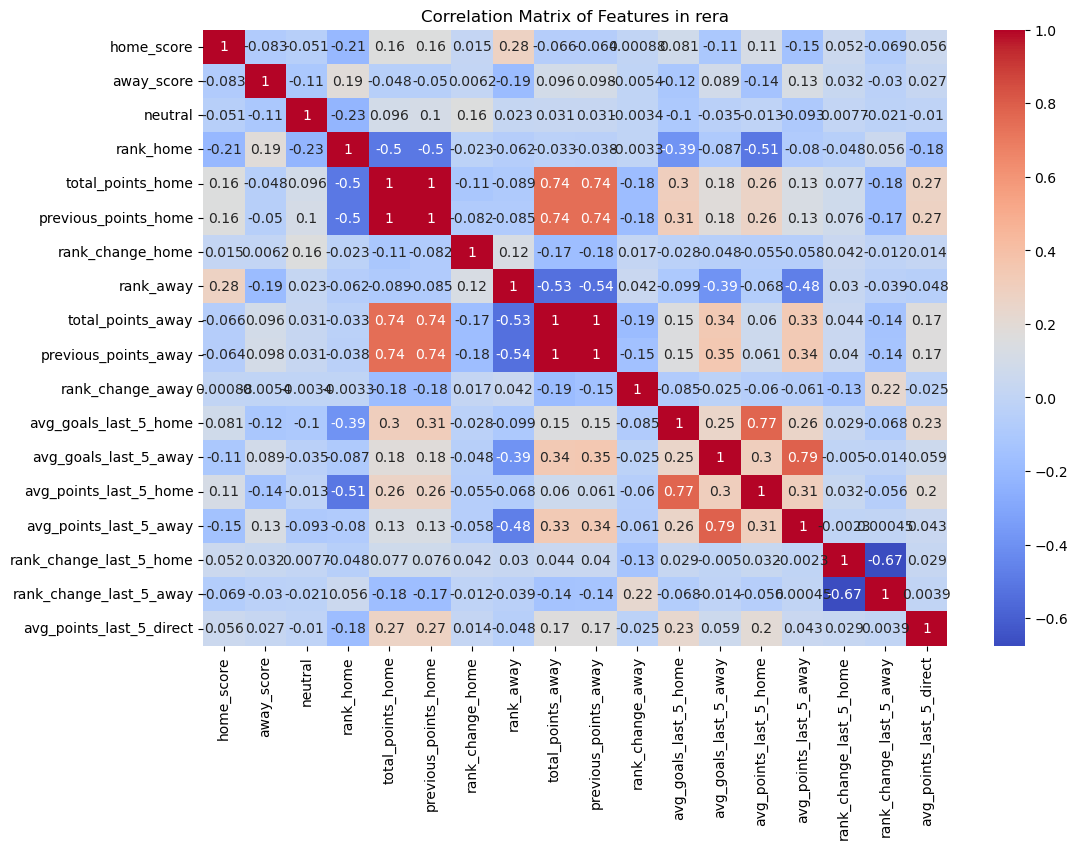

In [23]:
# Compute the correlation matrix
correlation_matrix = rera.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Features in rera")
plt.show()



_The correlation analysis reveals significant patterns among the features. Strong positive correlations, nearing 1, are identified, such as between total_points_home and previous_points_home (0.998811006) and total_points_away and previous_points_away (0.998665481). Conversely, robust negative correlations, close to -1, are evident, like those between rank_home and both total_points_home (-0.500838337) and previous_points_home (-0.503528607), with similar patterns for away teams. To address multicollinearity, it is advised to retain only one feature from each negatively correlated pair. Moreover, intriguing correlations, demanding further exploration, are noted. However, correlations with the target variables (home_score and away_score) are relatively weak, indicating a limited linear relationship._

## 4 Final tweaking

Perform a last check for dropping from <code>rera</code> all columns which are not essential or which contain redundant
information. Drop all rows which still contain missing data.

In [24]:
rera.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 320 entries, 0 to 319
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      320 non-null    datetime64[ns]
 1   home_team                 320 non-null    object        
 2   away_team                 320 non-null    object        
 3   home_score                320 non-null    int64         
 4   away_score                320 non-null    int64         
 5   tournament                320 non-null    object        
 6   city                      320 non-null    object        
 7   country                   320 non-null    object        
 8   neutral                   320 non-null    bool          
 9   rank_home                 320 non-null    float64       
 10  total_points_home         320 non-null    float64       
 11  previous_points_home      320 non-null    float64       
 12  rank_change_home      

In [25]:
rera.to_csv('rera.csv')